In [27]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import shap
import warnings
warnings.filterwarnings('ignore')

# фиксируем для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("s3programmer/disease-diagnosis-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'disease-diagnosis-dataset' dataset.
Path to dataset files: /kaggle/input/disease-diagnosis-dataset


In [29]:
from pathlib import Path

In [30]:
dataset_path = Path("/root/.cache/kagglehub/datasets/s3programmer/disease-diagnosis-dataset/versions/1")
csv_file = dataset_path / "disease_diagnosis.csv"

In [31]:
df = pd.read_csv(csv_file)

In [32]:
df.shape

(2000, 13)

In [33]:
target_columns = ['Diagnosis', 'Severity', 'Treatment_Plan']

In [34]:
symptoms_1 = set(df['Symptom_1'].unique())
symptoms_2 = set(df['Symptom_2'].unique())
symptoms_3 = set(df['Symptom_3'].unique())

all_symptoms = symptoms_1.union(symptoms_2).union(symptoms_3)

In [35]:
# Создание бинарных признаков симптомов
def create_symptom_features(df):
    df_processed = df.copy()

    for symptom in all_symptoms:
        symptom_col_name = f'has_{symptom.replace(" ", "_").lower()}'
        df_processed[symptom_col_name] = (
            (df['Symptom_1'] == symptom) |
            (df['Symptom_2'] == symptom) |
            (df['Symptom_3'] == symptom)
        ).astype(int)

    df_processed = df_processed.drop(['Symptom_1', 'Symptom_2', 'Symptom_3'], axis=1)

    return df_processed

df_processed = create_symptom_features(df)

In [36]:
# Подготовка признаков и целевых переменных
symptom_columns = [col for col in df_processed.columns if col.startswith('has_')]
print(f"Создано {len(symptom_columns)} бинарных признаков симптомов")

X = df_processed.drop(target_columns + ['Patient_ID', 'Blood_Pressure_mmHg'], axis=1)
y = df_processed[target_columns]

print(f"Признаки: {X.shape[1]}")
print(f"Целевые : {list(y.columns)}")

Создано 8 бинарных признаков симптомов
Признаки: 13
Целевые : ['Diagnosis', 'Severity', 'Treatment_Plan']


In [37]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y['Diagnosis']
)

print(f"Размеры данных:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Размеры данных:
X_train: (1600, 13), X_test: (400, 13)
y_train: (1600, 3), y_test: (400, 3)


In [38]:
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
categorical_features = ['Gender']

print("Структура признаков:")
print(f"Числовые: {numerical_features}")
print(f"Категориальные: {categorical_features}")
print(f"Бинарные симптомы: {len(symptom_columns)} признаков")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

Структура признаков:
Числовые: ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
Категориальные: ['Gender']
Бинарные симптомы: 8 признаков


In [39]:
# Бейзлайн модель
dummy_models = {}
dummy_scores = {}

for target in target_columns:
    print(f"{target}:")
    print("-" * 30)

    dummy_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
    ])

    dummy_pipeline.fit(X_train, y_train[target])
    y_pred_dummy = dummy_pipeline.predict(X_test)

    precision_macro = precision_score(y_test[target], y_pred_dummy, average='macro', zero_division=0)
    recall_macro = recall_score(y_test[target], y_pred_dummy, average='macro', zero_division=0)
    f1_macro = f1_score(y_test[target], y_pred_dummy, average='macro', zero_division=0)

    dummy_scores[target] = {
        'precision': precision_macro,
        'recall': recall_macro,
        'f1': f1_macro
    }
    dummy_models[target] = dummy_pipeline

    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")

Diagnosis:
------------------------------
Macro Precision: 0.1165
Macro Recall: 0.2000
Macro F1-score: 0.1472
Severity:
------------------------------
Macro Precision: 0.2217
Macro Recall: 0.3333
Macro F1-score: 0.2663
Treatment_Plan:
------------------------------
Macro Precision: 0.2217
Macro Recall: 0.3333
Macro F1-score: 0.2663


In [40]:
# показатели низкие

In [41]:
# Средние метрики бейзлайна
mean_dummy_f1 = np.mean([score['f1'] for score in dummy_scores.values()])
mean_dummy_precision = np.mean([score['precision'] for score in dummy_scores.values()])
mean_dummy_recall = np.mean([score['recall'] for score in dummy_scores.values()])

print(f"СРЕДНИЕ МЕТРИКИ DUMMY CLASSIFIER:")
print(f"Macro Precision: {mean_dummy_precision:.4f}")
print(f"Macro Recall: {mean_dummy_recall:.4f}")
print(f"Macro F1-score: {mean_dummy_f1:.4f}")

СРЕДНИЕ МЕТРИКИ DUMMY CLASSIFIER:
Macro Precision: 0.1866
Macro Recall: 0.2889
Macro F1-score: 0.2266


In [42]:
# Decision Tree модель
dt_models = {}
dt_scores = {}

for target in target_columns:
    print(f"{target}:")
    print("-" * 30)

    dt_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    dt_pipeline.fit(X_train, y_train[target])
    y_pred_dt = dt_pipeline.predict(X_test)

    precision_macro = precision_score(y_test[target], y_pred_dt, average='macro', zero_division=0)
    recall_macro = recall_score(y_test[target], y_pred_dt, average='macro', zero_division=0)
    f1_macro = f1_score(y_test[target], y_pred_dt, average='macro', zero_division=0)

    dt_scores[target] = {
        'precision': precision_macro,
        'recall': recall_macro,
        'f1': f1_macro
    }
    dt_models[target] = dt_pipeline

    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")

    improvement = f1_macro - dummy_scores[target]['f1']
    improvement_pct = (improvement / dummy_scores[target]['f1']) * 100 if dummy_scores[target]['f1'] > 0 else np.inf
    print(f"Улучшение над бейзлайном: {improvement:+.4f} ({improvement_pct:+.1f}%)")

Diagnosis:
------------------------------
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Улучшение над бейзлайном: +0.8528 (+579.2%)
Severity:
------------------------------
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Улучшение над бейзлайном: +0.7337 (+275.6%)
Treatment_Plan:
------------------------------
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Улучшение над бейзлайном: +0.7337 (+275.6%)


In [43]:
# Средние метрики Decision Tree
mean_dt_f1 = np.mean([score['f1'] for score in dt_scores.values()])
mean_dt_precision = np.mean([score['precision'] for score in dt_scores.values()])
mean_dt_recall = np.mean([score['recall'] for score in dt_scores.values()])

print(f" МЕТРИКИ DECISION TREE:")
print(f"Macro Precision: {mean_dt_precision:.4f}")
print(f"Macro Recall: {mean_dt_recall:.4f}")
print(f"Macro F1-score: {mean_dt_f1:.4f}")
print(f"Средний F1 бейзлайна: {mean_dummy_f1:.4f}")
print(f"Средний F1 Decision Tree: {mean_dt_f1:.4f}")
print(f"Абсолютное улучшение: {mean_dt_f1 - mean_dummy_f1:+.4f}")
print(f"Относительное улучшение F1 над бейзлайном: {((mean_dt_f1 - mean_dummy_f1) / mean_dummy_f1) * 100:+.2f}%")

 МЕТРИКИ DECISION TREE:
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Средний F1 бейзлайна: 0.2266
Средний F1 Decision Tree: 1.0000
Абсолютное улучшение: +0.7734
Относительное улучшение F1 над бейзлайном: +341.33%


Всего признаков: 13
Глубина дерева: 5
Количество листьев: 18


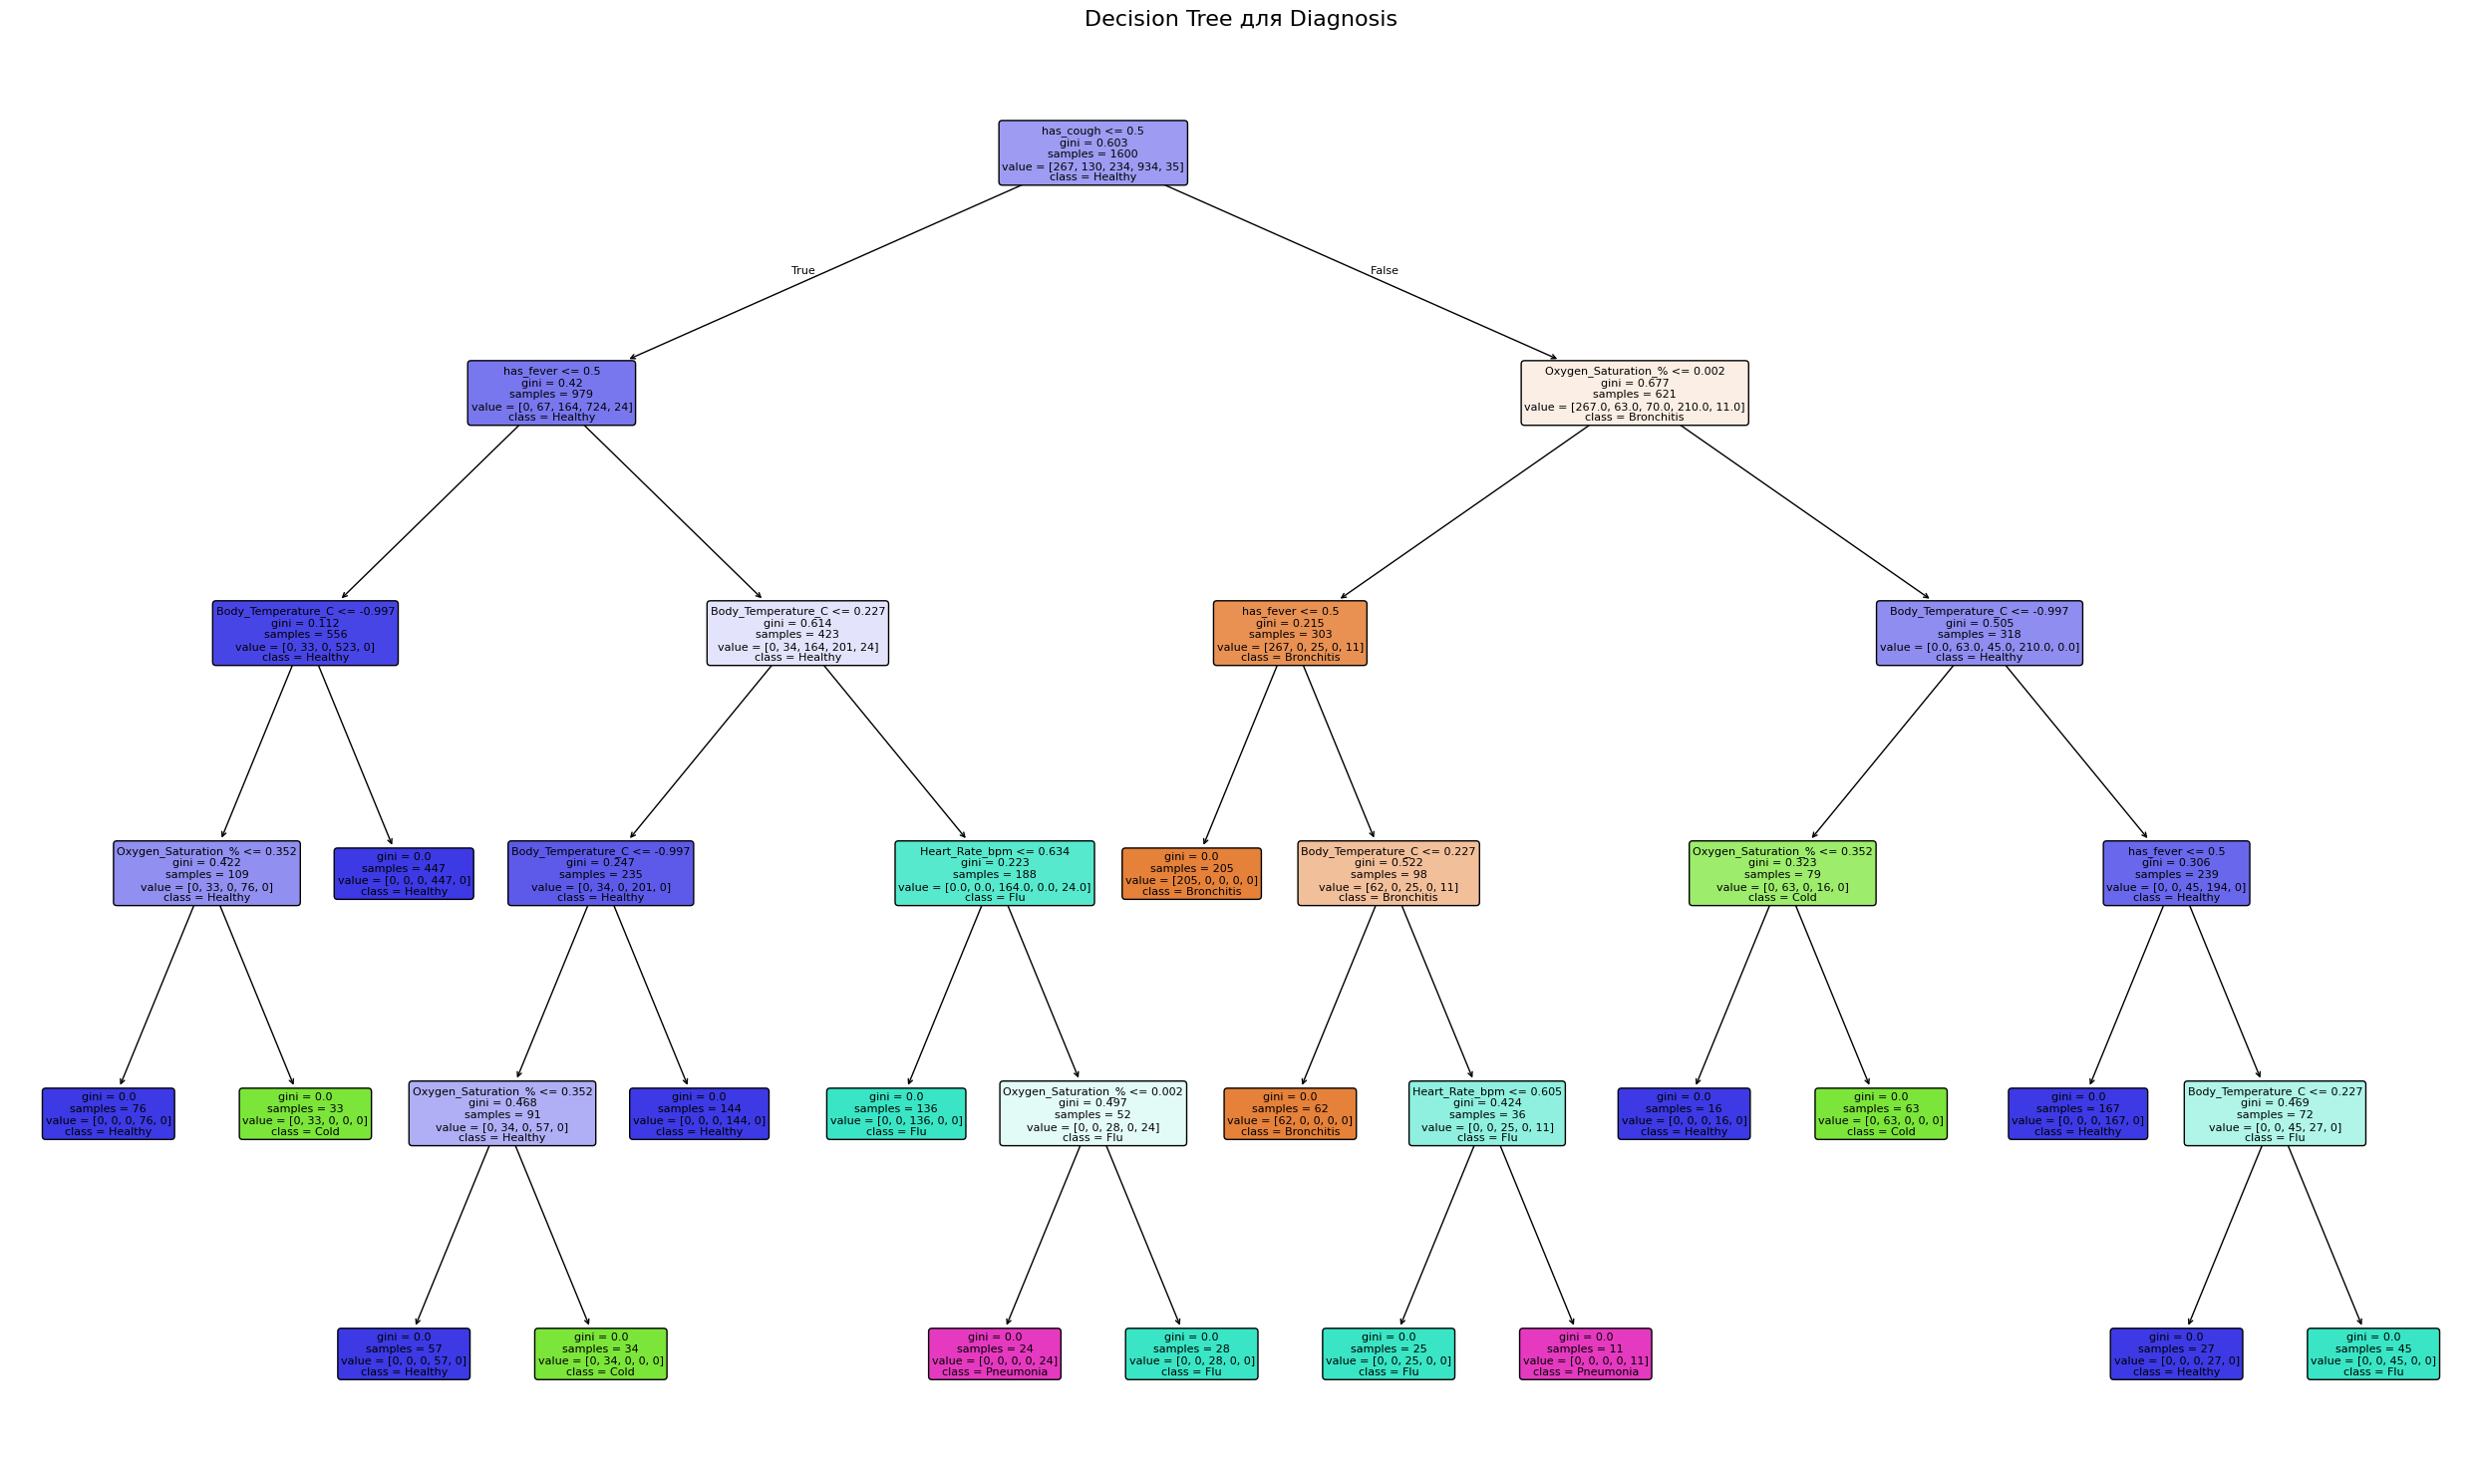

In [44]:
# рисуем деревья с решающими правилами для всех трёх целевых

dt_diagnosis = dt_models['Diagnosis']

numerical_names = numerical_features
categorical_names = list(dt_diagnosis.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features))
all_feature_names = numerical_names + categorical_names + symptom_columns

print(f"Всего признаков: {len(all_feature_names)}")
print(f"Глубина дерева: {dt_diagnosis.named_steps['model'].get_depth()}")
print(f"Количество листьев: {dt_diagnosis.named_steps['model'].get_n_leaves()}")

plt.figure(figsize=(25, 15))
plot_tree(dt_diagnosis.named_steps['model'],
          feature_names=all_feature_names,
          class_names=list(dt_diagnosis.named_steps['model'].classes_),
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=5)
plt.title('Decision Tree для Diagnosis', fontsize=16)
plt.tight_layout()
plt.show()


Diagnosis - Топ-5 важных признаков:
  1. Oxygen_Saturation_%: 0.3472
  2. Body_Temperature_C: 0.3348
  3. has_fever: 0.1477
  4. has_cough: 0.1379
  5. Heart_Rate_bpm: 0.0325

Severity - Топ-5 важных признаков:
  1. Oxygen_Saturation_%: 0.3387
  2. Body_Temperature_C: 0.3140
  3. has_fever: 0.1576
  4. has_cough: 0.1507
  5. Heart_Rate_bpm: 0.0391

Treatment_Plan - Топ-5 важных признаков:
  1. Oxygen_Saturation_%: 0.3387
  2. Body_Temperature_C: 0.3140
  3. has_fever: 0.1576
  4. has_cough: 0.1507
  5. Heart_Rate_bpm: 0.0391


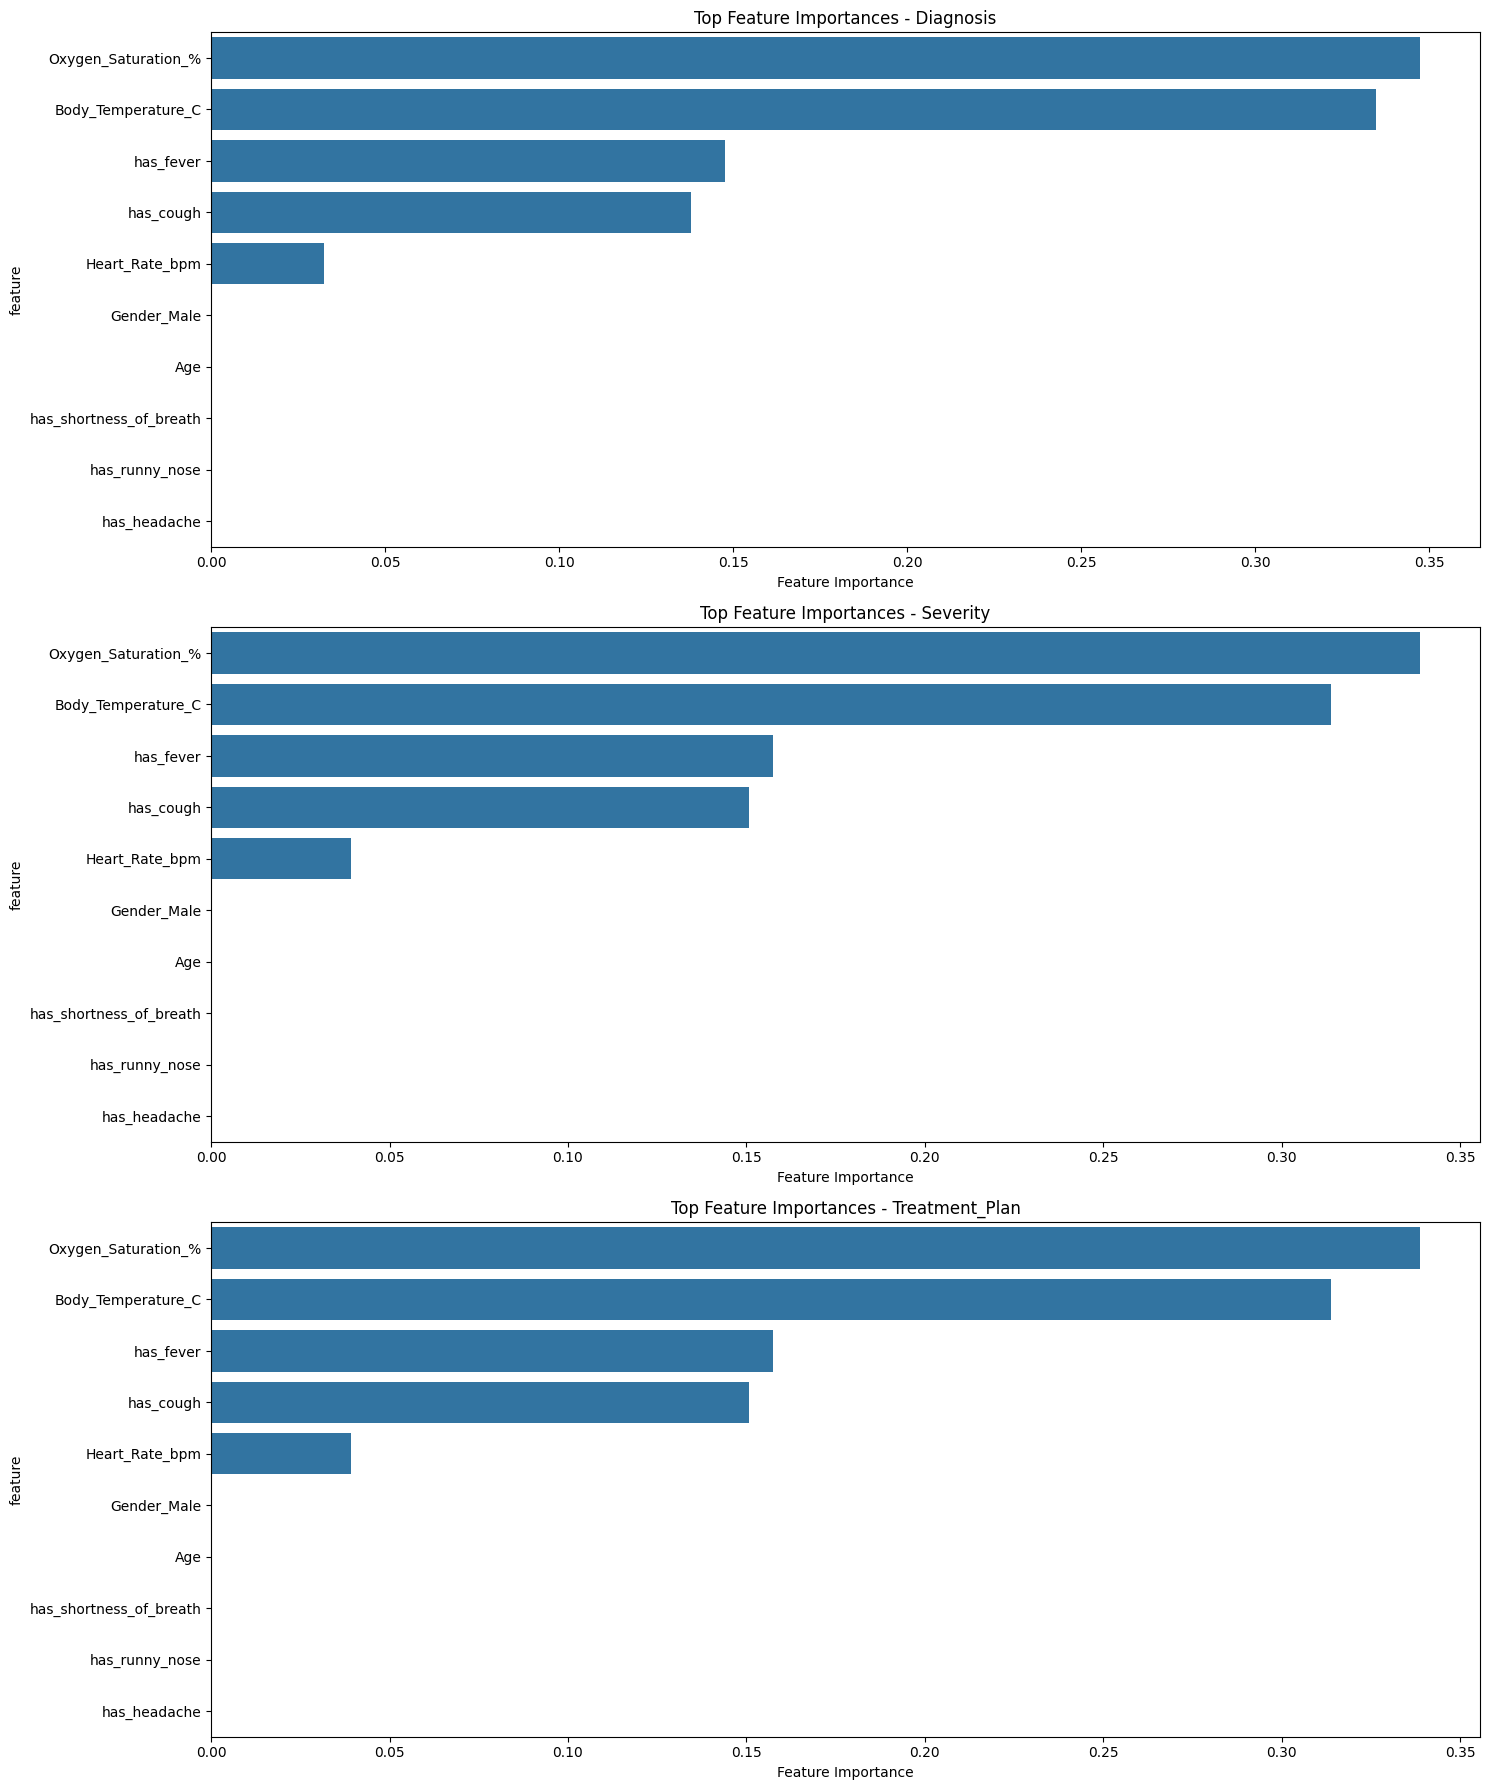

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

for i, target in enumerate(target_columns):
    dt_model = dt_models[target]
    feature_importance = dt_model.named_steps['model'].feature_importances_

    importance_df = pd.DataFrame({
        'feature': all_feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False).head(10)

    sns.barplot(data=importance_df, x='importance', y='feature', ax=axes[i])
    axes[i].set_title(f'Top Feature Importances - {target}')
    axes[i].set_xlabel('Feature Importance')

    print(f"\n{target} - Топ-5 важных признаков:")
    for j, (_, row) in enumerate(importance_df.head(5).iterrows(), 1):
        print(f"  {j}. {row['feature']}: {row['importance']:.4f}")

plt.tight_layout()
plt.show()